In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix
from xgboost import XGBClassifier
import joblib


In [3]:
df1=pd.read_excel('Customer_Churn_Data.xlsx',sheet_name='vw_churn')

In [4]:
df_c=df1.drop(columns=['Customer_ID','Churn_Category','Churn_Reason'],axis=1).copy()

In [5]:
#df_c['Value_Deal']=df_c['Value_Deal'].astype(int)

In [6]:
#df_c['Internet_Type']=df_c['Internet_Type'].astype(int)


In [7]:
df_c['Customer_Status']=df_c['Customer_Status'].map({'Stayed':0,'Churned':1})

In [8]:
features=df_c.drop(columns=['Customer_Status'])
target=df_c['Customer_Status']

In [9]:
x_train,x_test,y_train,y_test=train_test_split(features,target,test_size=0.2,random_state=42)

In [10]:
cate_col = [
    'Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service',
    'Multiple_Lines', 'Internet_Service', 'Internet_Type',
    'Online_Security', 'Online_Backup', 'Device_Protection_Plan',
    'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
    'Streaming_Music', 'Unlimited_Data', 'Contract',
    'Paperless_Billing', 'Payment_Method'
]

In [11]:
cate_pipeline=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
    
])

In [12]:
preprocessing=ColumnTransformer(transformers=[
    ('cate',cate_pipeline,cate_col)
],remainder='passthrough')

In [13]:
model=Pipeline(steps=[
    ('preprocessing',preprocessing),
    ('classifier',XGBClassifier(n_estimators=100,max_depth=5,learning_rate=0.1,random_state=42))
])

In [14]:
model.fit(x_train,y_train)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cate', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [15]:
y_pred=model.predict(x_test)

In [16]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [17]:
print('classification_report',classification_report(y_test,y_pred))
print('accuracy_score',round(accuracy_score(y_test,y_pred)*100,2))

classification_report               precision    recall  f1-score   support

           0       0.87      0.91      0.89       847
           1       0.76      0.68      0.72       355

    accuracy                           0.84      1202
   macro avg       0.82      0.80      0.81      1202
weighted avg       0.84      0.84      0.84      1202

accuracy_score 84.44


In [18]:
print('confusion_matrix :')
print(confusion_matrix(y_test,y_pred))

confusion_matrix :
[[772  75]
 [112 243]]


In [19]:
result=pd.DataFrame({
    'Actual':y_test,
    'Predicted':y_pred
})
result.to_csv('output.csv',index=False)
print('Successfully save the file...')

Successfully save the file...


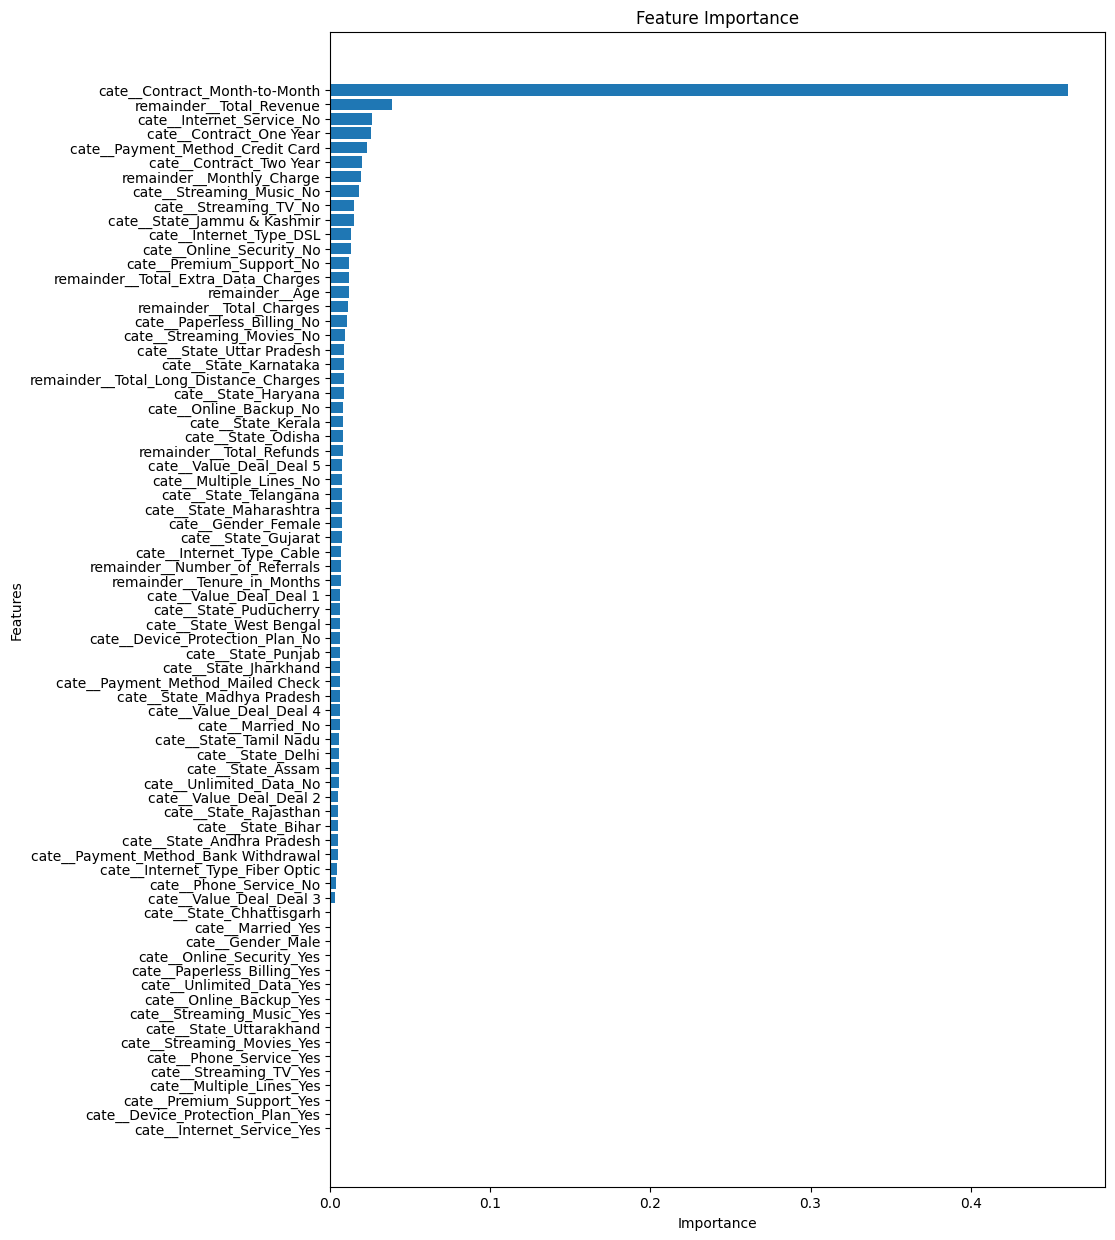

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# importance values
importances = model.named_steps['classifier'].feature_importances_

# transformed feature names
features = model.named_steps['preprocessing'].get_feature_names_out()

# sorting
indices = np.argsort(importances)

# plot
plt.figure(figsize=(10,15))

plt.barh(
    features[indices],
    importances[indices]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")

plt.show()

In [31]:
new_data=pd.read_excel('Customer_Churn_Data.xlsx',sheet_name='vw_join')

In [32]:
orignal_data=new_data.copy()

In [33]:
customer_id=new_data['Customer_ID']

In [34]:
# drop unwanted columns
new_data =new_data.drop(
    columns=['Customer_ID','Churn_Category','Churn_Reason','Customer_Status'],
    errors='ignore')

In [35]:
y_pred=model.predict(new_data)

In [36]:
orignal_data['Predicted_Customer_Status']=y_pred
orignal_data=orignal_data[orignal_data['Predicted_Customer_Status']==1]

In [37]:
orignal_data.to_csv('predicted.csv',index=False)